In [1]:
# !pip install pandas

Saved processed data to: slinky_pulling_force_data_exact.npz
Number of samples: 50
Initial displacement: 0.2881684163230799
Final displacement: 0.4712011868763382


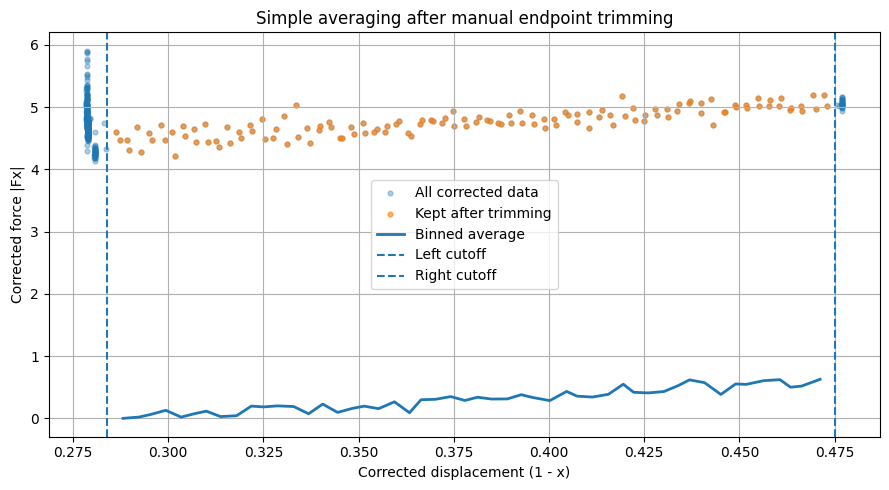

x_trim.shape (128,)


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_force_displacement_from_csv(csv_file: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load x displacement and Fx force from CSV.
    """
    df = pd.read_csv(csv_file)

    if "x" not in df.columns or "Fx" not in df.columns:
        raise ValueError("CSV must contain columns 'x' and 'Fx'.")

    x = df["x"].to_numpy(dtype=float)
    Fx = df["Fx"].to_numpy(dtype=float)
    return x, Fx


def apply_sign_and_displacement_corrections(
    x: np.ndarray,
    Fx: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Apply the requested corrections:
    - corrected displacement = 1 - x
    - corrected force = abs(Fx)
    """
    x_corr = 1.0 - x
    Fx_corr = np.abs(Fx)
    return x_corr, Fx_corr


def sort_by_displacement(
    x: np.ndarray,
    Fx: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Sort data by corrected displacement.
    """
    idx = np.argsort(x)
    return x[idx], Fx[idx]


def trim_by_manual_cutoffs(
    x: np.ndarray,
    Fx: np.ndarray,
    x_min_keep: float,
    x_max_keep: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Keep only data in the displacement interval [x_min_keep, x_max_keep].
    """
    mask = (x >= x_min_keep) & (x <= x_max_keep)
    return x[mask], Fx[mask]

def shift_force_to_zero_reference(
    Fx: np.ndarray,
) -> np.ndarray:
    """
    Shift force so that the first value is zero.

    This enforces zero force at the reference configuration:
        F_new = F - F[0]

    Assumes Fx is ordered by increasing displacement.
    """
    if len(Fx) == 0:
        return Fx

    return Fx - Fx[0]


def average_in_displacement_bins(
    x: np.ndarray,
    Fx: np.ndarray,
    num_bins: int = 30,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Simple averaging inside displacement bins.

    This reduces noise while keeping the processing minimal.
    """
    if len(x) == 0:
        return np.array([]), np.array([])

    bin_edges = np.linspace(x.min(), x.max(), num_bins + 1)

    x_avg_list = []
    F_avg_list = []

    for i in range(num_bins):
        left = bin_edges[i]
        right = bin_edges[i + 1]

        if i < num_bins - 1:
            mask = (x >= left) & (x < right)
        else:
            mask = (x >= left) & (x <= right)

        if np.any(mask):
            x_avg_list.append(np.mean(x[mask]))
            F_avg_list.append(np.mean(Fx[mask]))

    return np.array(x_avg_list), np.array(F_avg_list)


def save_training_data(
    save_file: str,
    disps: np.ndarray,
    forces: np.ndarray,
) -> None:
    """
    Save processed data in training format.
    """
    np.savez(
        save_file,
        F=forces,
        disps=disps,
        initial_last_node_x=float(disps[0]),
        final_last_node_x=float(disps[-1]),
    )

    print(f"Saved processed data to: {save_file}")
    print(f"Number of samples: {len(disps)}")
    print(f"Initial displacement: {disps[0]}")
    print(f"Final displacement: {disps[-1]}")


def plot_processed_data(
    x_sorted: np.ndarray,
    F_sorted: np.ndarray,
    x_trim: np.ndarray,
    F_trim: np.ndarray,
    x_avg: np.ndarray,
    F_avg: np.ndarray,
    x_min_keep: float,
    x_max_keep: float,
) -> None:
    """
    Plot:
    - all corrected data
    - trimmed data
    - averaged curve
    - manual cutoff lines
    """
    plt.figure(figsize=(9, 5))

    plt.scatter(x_sorted, F_sorted, s=12, alpha=0.35, label="All corrected data")
    plt.scatter(x_trim, F_trim, s=12, alpha=0.6, label="Kept after trimming")
    plt.plot(x_avg, F_avg, linewidth=2, label="Binned average")

    plt.axvline(x_min_keep, linestyle="--", linewidth=1.5, label="Left cutoff")
    plt.axvline(x_max_keep, linestyle="--", linewidth=1.5, label="Right cutoff")

    plt.xlabel("Corrected displacement (1 - x)")
    plt.ylabel("Corrected force |Fx|")
    plt.title("Simple averaging after manual endpoint trimming")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def process_csv_with_manual_cutoffs(
    csv_file: str,
    save_file: str = "slinky_pulling_force_data_exact.npz",
    x_min_keep: float = 0.285,
    x_max_keep: float = 0.470,
    num_bins: int = 30,
    make_plot: bool = True,
) -> dict:
    """
    Full minimal pipeline:
    - load all data
    - apply sign/displacement corrections
    - sort by displacement
    - trim by manual left/right cutoffs
    - do simple bin averaging
    - save in training format
    """
    # Load raw data
    x_raw, Fx_raw = load_force_displacement_from_csv(csv_file)

    # Apply corrections
    x_corr, Fx_corr = apply_sign_and_displacement_corrections(x_raw, Fx_raw)

    # Sort corrected data
    x_sorted, F_sorted = sort_by_displacement(x_corr, Fx_corr)

    # Manually trim endpoint chunks
    x_trim, F_trim = trim_by_manual_cutoffs(
        x_sorted, F_sorted, x_min_keep=x_min_keep, x_max_keep=x_max_keep
    )

    # Average in bins
    x_avg, F_avg = average_in_displacement_bins(x_trim, F_trim, num_bins=num_bins)
    
    # ---- NEW: shift force so first value is zero ----
    F_avg = shift_force_to_zero_reference(F_avg)

    # Save processed curve
    save_training_data(save_file, x_avg, F_avg)

    # Optional plot
    if make_plot:
        plot_processed_data(
            x_sorted, F_sorted, x_trim, F_trim, x_avg, F_avg, x_min_keep, x_max_keep
        )

    return {
        "x_raw": x_raw,
        "Fx_raw": Fx_raw,
        "x_corr": x_corr,
        "Fx_corr": Fx_corr,
        "x_sorted": x_sorted,
        "F_sorted": F_sorted,
        "x_trim": x_trim,
        "F_trim": F_trim,
        "x_avg": x_avg,
        "F_avg": F_avg,
    }


if __name__ == "__main__":
    result = process_csv_with_manual_cutoffs(
        csv_file="ee_pose_force.csv",
        save_file="slinky_pulling_force_data_exact.npz",
        x_min_keep=0.284,   # choose manually
        x_max_keep=0.475,   # choose manually
        num_bins=50,
        make_plot=True,
    )
    print("x_trim.shape", result["x_trim"].shape)

In [3]:
import numpy as np
import pandas as pd


# =========================================================
# Load CSV
# =========================================================
csv_file = "ee_pose_force.csv"
df = pd.read_csv(csv_file)

# Keep only the columns we care about
x = df["x"].to_numpy()
Fx = df["Fx"].to_numpy()


# =========================================================
# Choose one branch only (pulling or return)
# =========================================================
# Since the experiment contains pull + return, and x is the imposed
# displacement coordinate, we keep only one monotonic branch.
#
# We detect the turning point from x:
# - if motion starts near max and goes down first, keep start -> min(x)
# - if motion starts near min and goes up first, keep start -> max(x)

idx_min = np.argmin(x)
idx_max = np.argmax(x)

if idx_min < idx_max:
    # starts low, pulls upward first
    branch_end = idx_max
else:
    # starts high, pulls downward first
    branch_end = idx_min

x_branch = x[: branch_end + 1]
Fx_branch = Fx[: branch_end + 1]


# =========================================================
# Optional: remove duplicate displacement points
# =========================================================
# Repeated x values can happen from sensor sampling.
# For training, it is usually cleaner to collapse duplicates by averaging force.

unique_x, inverse = np.unique(x_branch, return_inverse=True)
Fx_avg = np.zeros_like(unique_x, dtype=float)
counts = np.zeros_like(unique_x, dtype=int)

for i, g in enumerate(inverse):
    Fx_avg[g] += Fx_branch[i]
    counts[g] += 1

Fx_avg = Fx_avg / counts


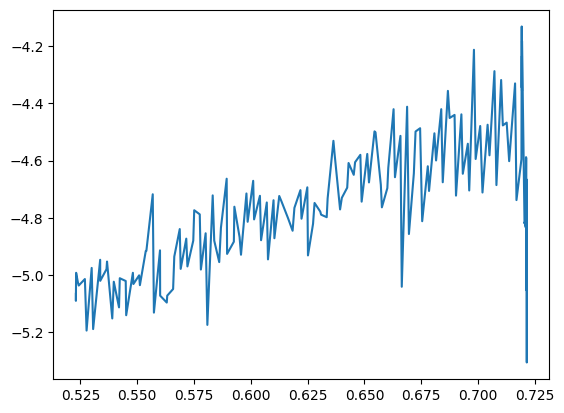

In [4]:
import matplotlib.pyplot as plt
# plot the data
plt.plot(unique_x, Fx_avg)
plt.show()


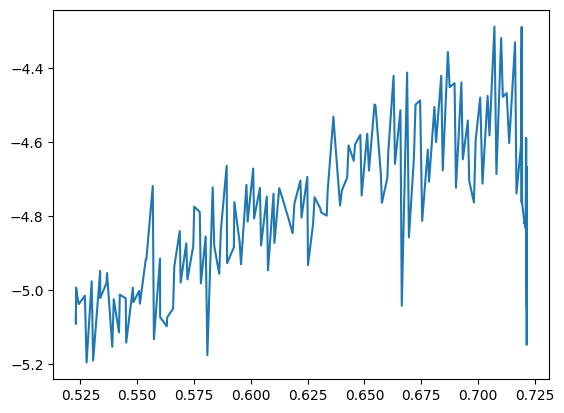

In [5]:
# remove outliers
median = np.median(Fx_avg)
mad = np.median(np.abs(Fx_avg - median))

threshold = 3 * mad
Fx_clean = np.where(
    np.abs(Fx_avg - median) > threshold,
    median,
    Fx_avg
)

# plot the cleaned data
plt.plot(unique_x, Fx_clean)
plt.show()


In [6]:
from scipy.signal import savgol_filter
from sklearn.isotonic import IsotonicRegression

# Step 1: smooth
Fx_smooth = savgol_filter(Fx_clean, 11, 2)

# Step 2: enforce monotonicity
iso = IsotonicRegression(increasing=True)
Fx_smooth = iso.fit_transform(unique_x, Fx_smooth)

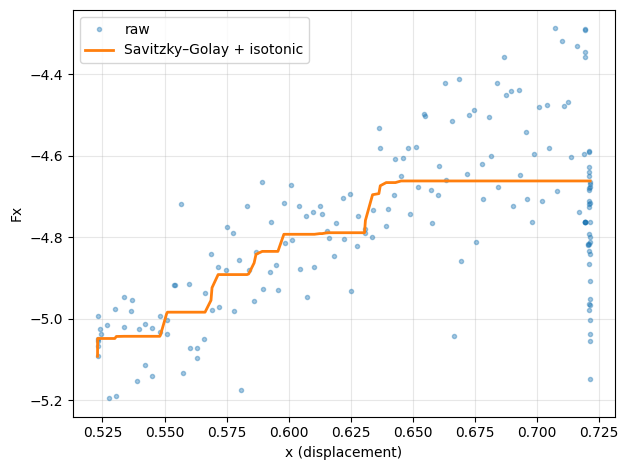

In [7]:
# Fx_smooth is aligned with x_branch (not unique_x — that array is shorter).
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(unique_x, Fx_clean, ".", alpha=0.4, label="raw")
ax.plot(unique_x, Fx_smooth, "-", lw=2, label="Savitzky–Golay + isotonic")
ax.set_xlabel("x (displacement)")
ax.set_ylabel("Fx")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


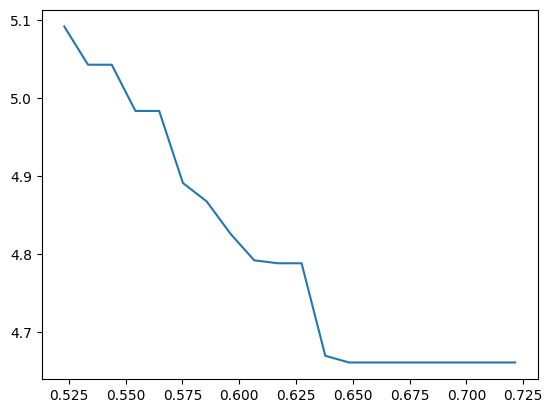

In [8]:
# get 20 equally spaced points from the data
# get 20 equallly spaced points from the data
num_points = 20
disps = np.linspace(unique_x[0], unique_x[-1], num_points)

# interpolate the force values at these displacements
forces = np.abs(np.interp(disps, unique_x, Fx_smooth))

# plot the data
plt.plot(disps, forces)
plt.show()




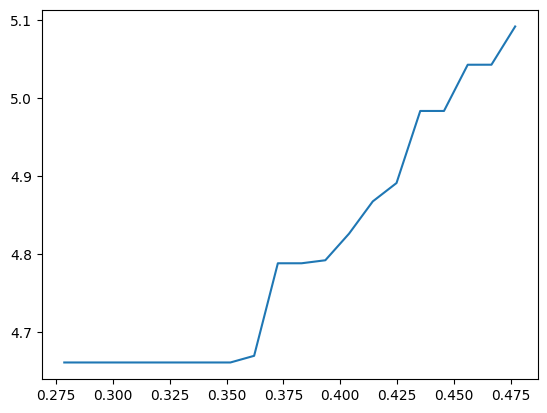

In [9]:
# use displacements as (1-displacement)
disps = 1 - disps
# plot the data
plt.plot(disps, forces)
plt.show()

